# Lab 3: California Housing — End-to-End Analysis

## 1. Load the Dataset

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split



In [ ]:
#loading dataset
df = pd.read_csv("housing.csv");
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [ ]:
#features of dataset
print("Dataframe information")
print("\n")
df.info()
print("\n")
print("Dataframe summary statistics")
df.describe()

Dataframe information


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Dataframe summary statistics


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
#target variable
target = "median_house_value"

x = df.drop(target,axis=1)
y = df[target]

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20)

print("X_train: \n")
print(x_train)
print("\nX_test: \n")
print(x_test)
print("\nY_train: \n")
print(y_train)
print("\nY_test: \n")
print(y_test)

X_train: 

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
14799    -117.11     32.58                12.0       1086.0           294.0   
10450    -117.67     33.44                25.0       2994.0           519.0   
6977     -118.02     33.98                23.0       1995.0           306.0   
19836    -119.40     36.53                28.0       2201.0           429.0   
5130     -118.27     33.98                39.0       2062.0           588.0   
...          ...       ...                 ...          ...             ...   
16885    -122.40     37.58                26.0       3281.0             NaN   
12293    -116.90     33.98                30.0       3915.0           672.0   
3582     -118.55     34.24                21.0       5751.0          1082.0   
4866     -118.28     34.04                25.0       1582.0           780.0   
7907     -118.09     33.85                19.0       8120.0          1371.0   

       population  households  median_in

## 2. Data Exploration and Cleaning

In [ ]:
# checking for missing values
print("Missing values per column:\n")
print(df.isnull().sum())
print("\nPercentage missing:\n")
print((df.isnull().sum() / len(df) * 100).round(2))


Missing values per column:

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Percentage missing:

longitude             0.0
latitude              0.0
housing_median_age    0.0
total_rooms           0.0
total_bedrooms        1.0
population            0.0
households            0.0
median_income         0.0
median_house_value    0.0
ocean_proximity       0.0
dtype: float64


In [ ]:
# imputing missing values in total_bedrooms with the median
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# confirm no missing values remain
df.isnull().sum()


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


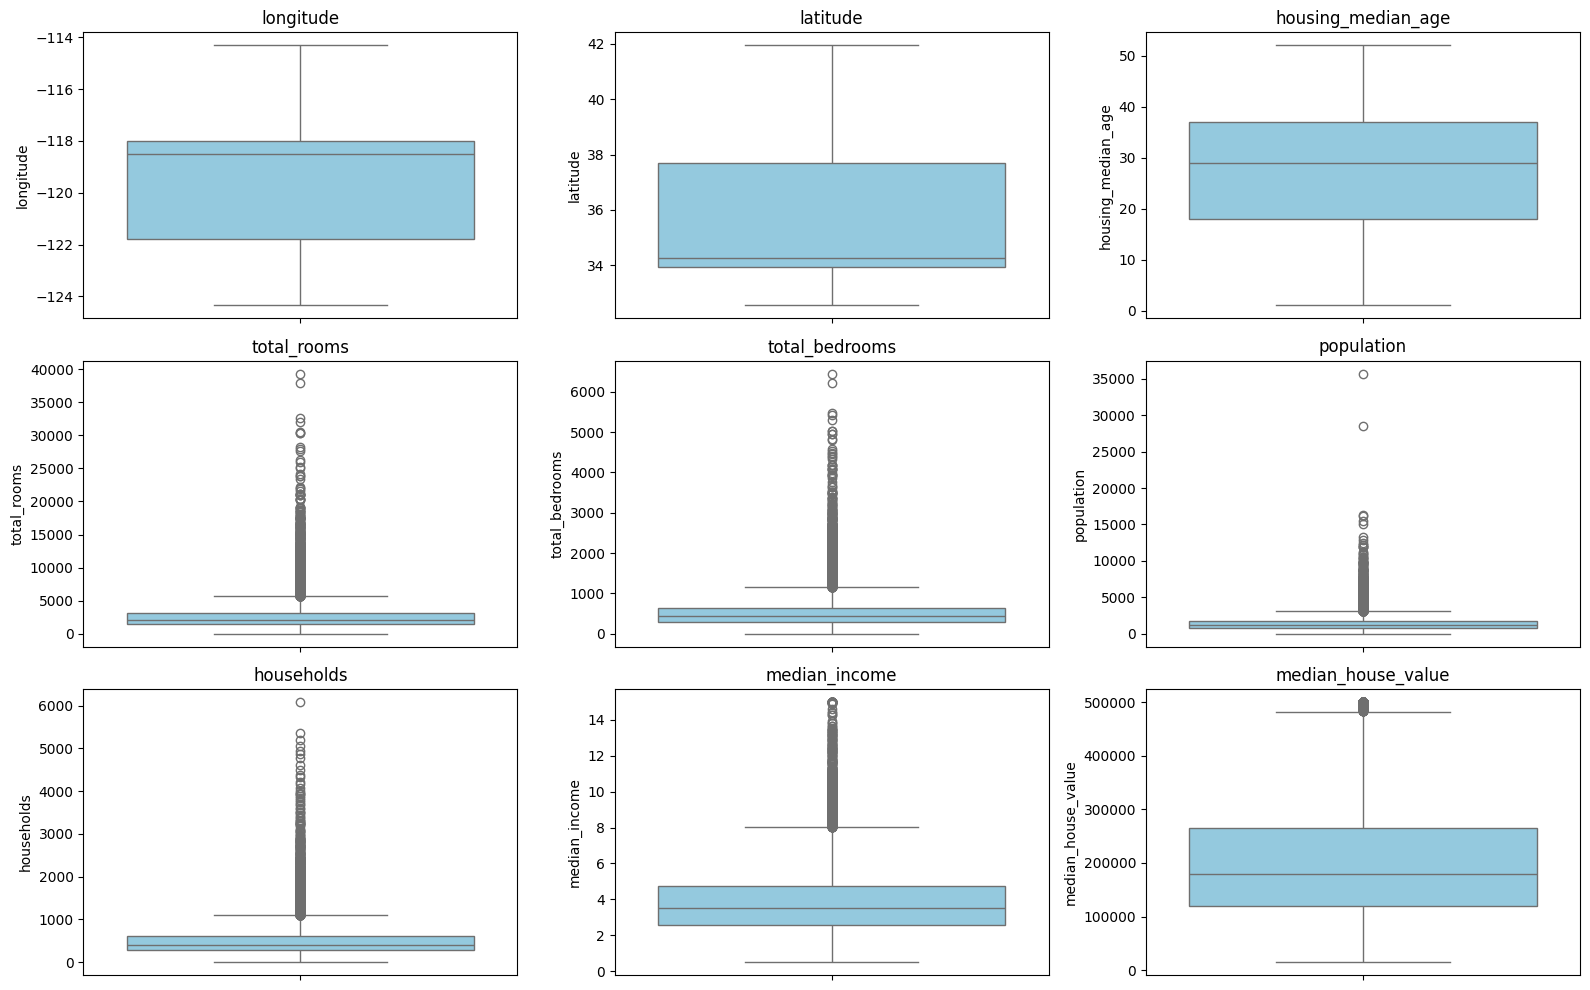

In [ ]:
# boxplots to visually inspect distributions and spot outliers
numeric_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(16, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)
    plt.tight_layout()
plt.show()


In [ ]:
#data exploration and cleaning
target = "median_house_value"

#dropping duplicates
df.drop_duplicates()

#removing outliers

q1 = df[target].quantile(0.25)
q3 = df[target].quantile(0.75)
iqr = q3-q1

low = q1-1.5 * iqr
up = q3+1.5*iqr

df = df[((df[target]>=low) & (df[target]<=up))]

df.shape


(19569, 10)

## 3. Univariate and Bivariate Analysis

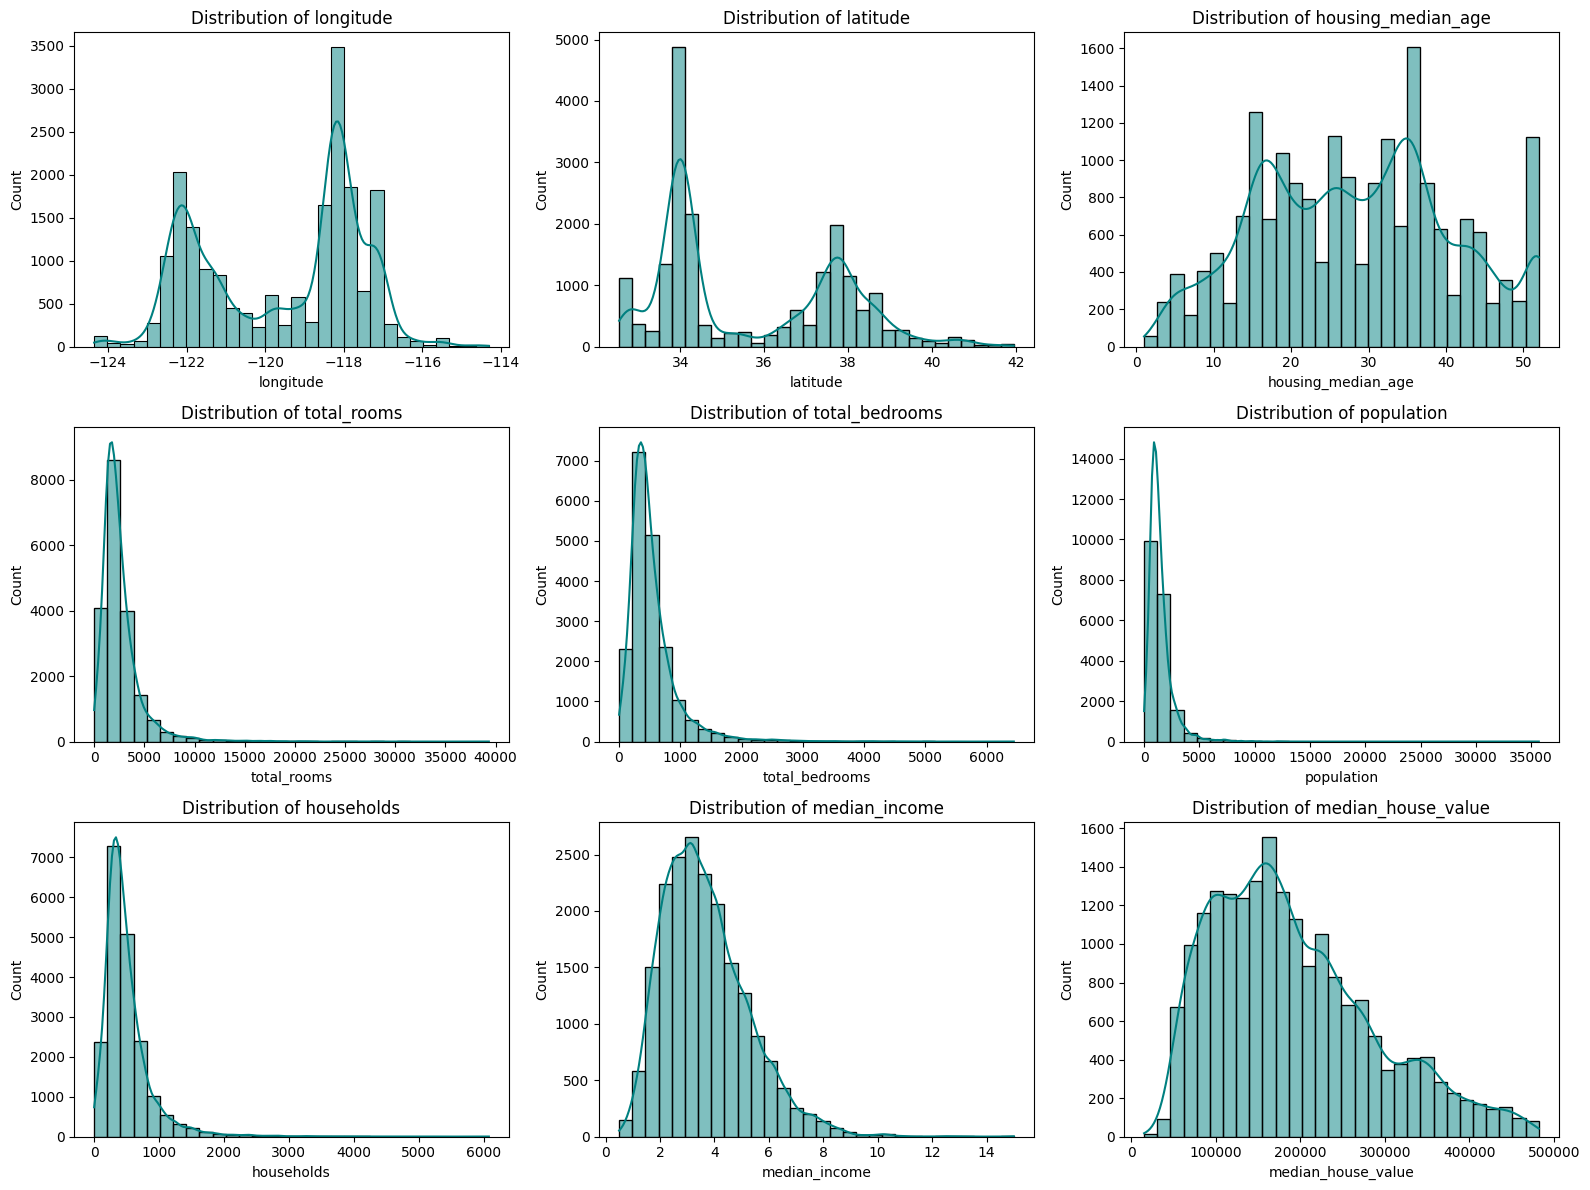

In [ ]:
# univariate analysis: histograms for feature distributions
numeric_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(16, 12))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, color='teal', bins=30)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()


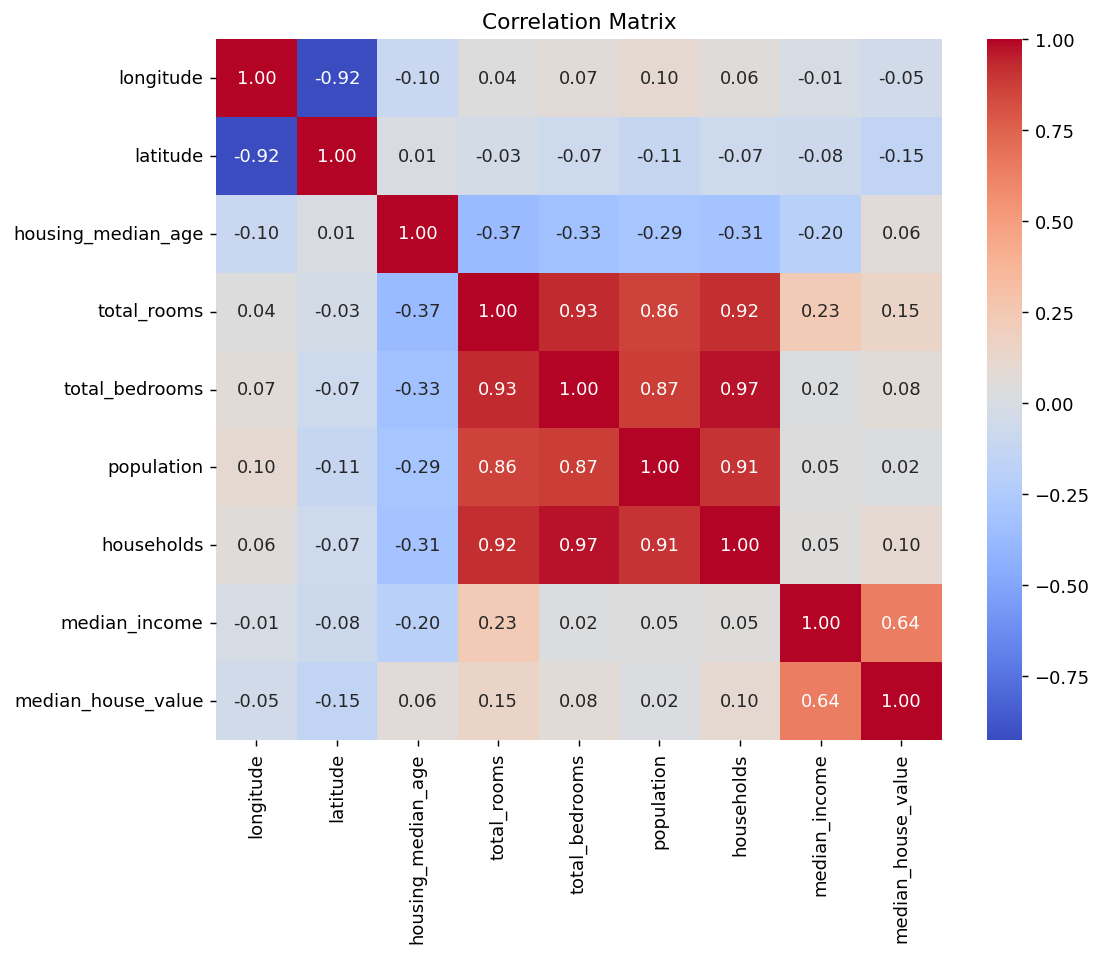

In [ ]:
# correlation matrix (numeric columns only)
corr = df.select_dtypes(include=[np.number]).corr()

plt.figure(dpi=130, figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


In [ ]:
# which features correlate most strongly (positively/negatively) with the target?
target_corr = corr['median_house_value'].drop('median_house_value').sort_values(ascending=False)
print("Correlation with median_house_value (sorted):\n")
print(target_corr)

print("\nStrongest positive correlation:", target_corr.idxmax(), "(%.2f)" % target_corr.max())
print("Strongest negative correlation:", target_corr.idxmin(), "(%.2f)" % target_corr.min())


Correlation with median_house_value (sorted):

median_income         0.644267
total_rooms           0.147526
households            0.099352
total_bedrooms        0.078093
housing_median_age    0.061480
population            0.017764
longitude            -0.047342
latitude             -0.149100
Name: median_house_value, dtype: float64

Strongest positive correlation: median_income (0.64)
Strongest negative correlation: latitude (-0.15)


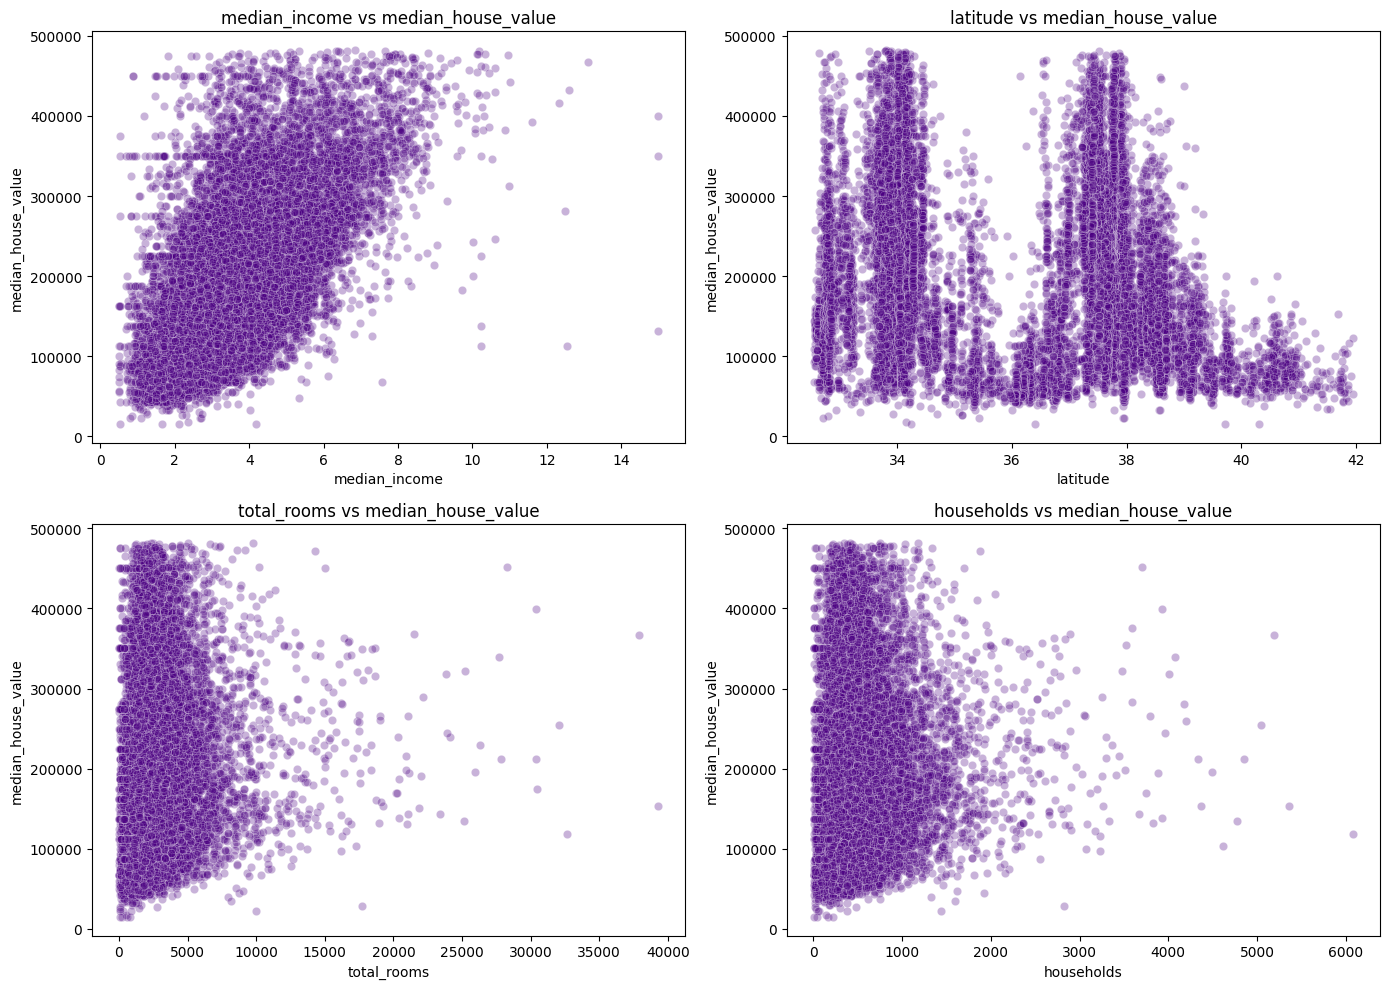

In [ ]:
# bivariate analysis: scatter plots of the top correlated features vs the target
top_features = target_corr.abs().sort_values(ascending=False).head(4).index

plt.figure(figsize=(14, 10))
for i, col in enumerate(top_features, 1):
    plt.subplot(2, 2, i)
    sns.scatterplot(x=df[col], y=df['median_house_value'], alpha=0.3, color='indigo')
    plt.title(f'{col} vs median_house_value')
    plt.tight_layout()
plt.show()
